# 04 — Analysis and Visualization
Answer the 3 core business questions with charts and statistical tests.

**Input:** `data/processed/daily_metrics.csv`, `data/processed/trader_summary.csv`
**Output:** Charts saved to `charts/`

In [3]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.config import DATA_PROCESSED, PALETTE
from src.utils import setup_plotting, save_chart, print_section
setup_plotting()
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load data

In [4]:
daily   = pd.read_csv(f'{DATA_PROCESSED}/daily_metrics.csv')
traders = pd.read_csv(f'{DATA_PROCESSED}/trader_summary.csv')
daily['date'] = pd.to_datetime(daily['date'])
fear  = daily[daily['Classification'] == 'Fear']
greed = daily[daily['Classification'] == 'Greed']
print(f'Daily metrics  : {daily.shape}')
print(f'Trader summary : {traders.shape}')

Daily metrics  : (77, 18)
Trader summary : (32, 14)


## 2. Q1 — Does PnL and win rate differ between Fear and Greed days?

In [5]:
q1 = daily.groupby('Classification').agg(
    mean_pnl   = ('daily_pnl', 'mean'),
    median_pnl = ('daily_pnl', 'median'),
    win_rate   = ('win_rate',  'mean'),
    std_pnl    = ('daily_pnl', 'std'),
).round(4)

t_stat, p_val = stats.ttest_ind(
    fear['daily_pnl'].dropna(),
    greed['daily_pnl'].dropna()
)
print_section('Q1 — PnL PERFORMANCE: FEAR vs GREED')
print(q1.T.to_string())
print(f'\nT-test p-value  : {p_val:.4f}')
print(f'Significant     : {"Yes" if p_val < 0.05 else "No"} (alpha=0.05)')


  Q1 — PnL PERFORMANCE: FEAR vs GREED
Classification        Fear       Greed
mean_pnl       171466.6892  90988.7034
median_pnl      46070.4936  20925.5132
win_rate            0.3848      0.3690
std_pnl        348594.8350 264805.4157

T-test p-value  : 0.2605
Significant     : No (alpha=0.05)


Chart saved: /app/charts/06_q1_performance.png


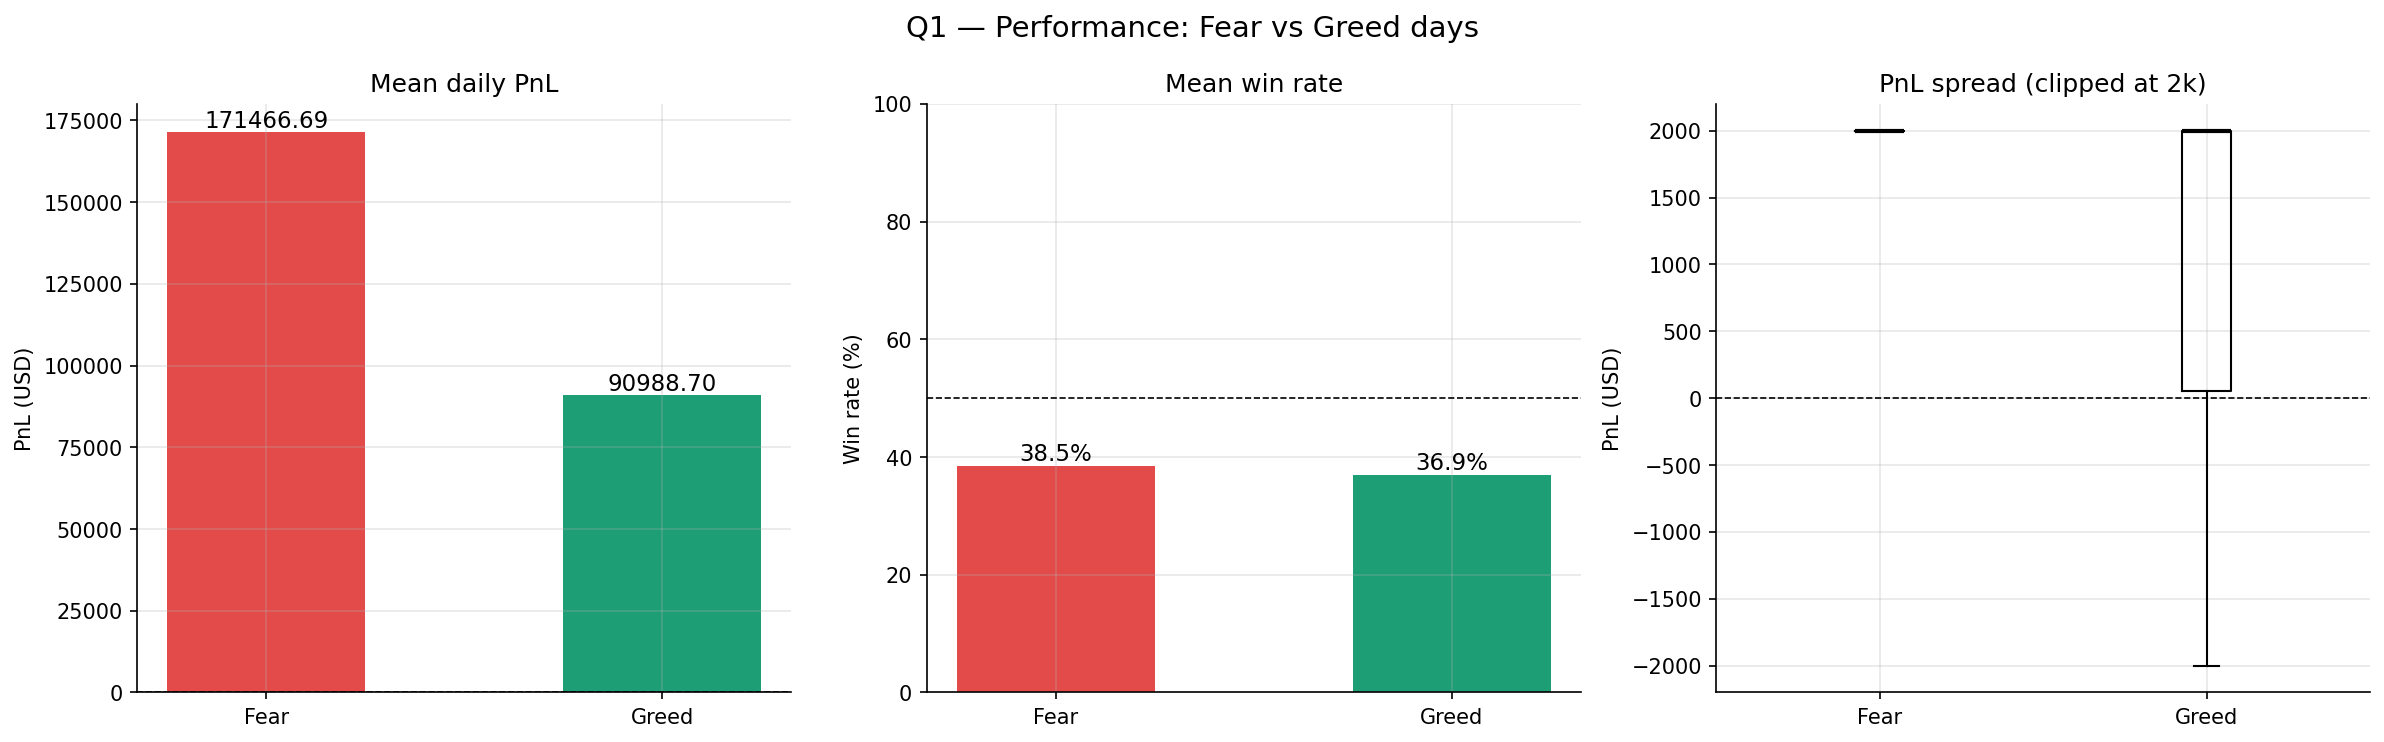

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = [PALETTE['Fear'], PALETTE['Greed']]
labels = ['Fear', 'Greed']

mean_pnl = [fear['daily_pnl'].mean(), greed['daily_pnl'].mean()]
bars = axes[0].bar(labels, mean_pnl, color=colors, width=0.5)
axes[0].set_title('Mean daily PnL')
axes[0].set_ylabel('PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, mean_pnl):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                 f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=11)

win_rates = [fear['win_rate'].mean(), greed['win_rate'].mean()]
bars2 = axes[1].bar(labels, [w*100 for w in win_rates], color=colors, width=0.5)
axes[1].set_title('Mean win rate')
axes[1].set_ylabel('Win rate (%)')
axes[1].axhline(50, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars2, win_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, val*100 + 1,
                 f'{val*100:.1f}%', ha='center', fontsize=11)

axes[2].boxplot(
    [fear['daily_pnl'].clip(-2000, 2000), greed['daily_pnl'].clip(-2000, 2000)],
    labels=labels, showfliers=False,
    medianprops=dict(color='black', linewidth=2)
)
axes[2].set_title('PnL spread (clipped at 2k)')
axes[2].set_ylabel('PnL (USD)')
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Q1 — Performance: Fear vs Greed days', fontsize=14)
plt.tight_layout()
save_chart(fig, '06_q1_performance.png')
plt.show()

## 3. Q2 — Do traders change behavior based on sentiment?

In [7]:
q2 = daily.groupby('Classification').agg(
    avg_trades   = ('num_trades',    'mean'),
    avg_size_usd = ('avg_size_usd',  'mean'),
    avg_buy_sell = ('buy_sell_ratio','mean'),
    avg_fee      = ('avg_fee',       'mean'),
).round(4)
print_section('Q2 — TRADER BEHAVIOR: FEAR vs GREED')
print(q2.T.to_string())


  Q2 — TRADER BEHAVIOR: FEAR vs GREED
Classification      Fear           Greed
avg_trades     3525.3000       1168.9459
avg_size_usd   5499.9070       5637.3024
avg_buy_sell      1.0232 8945945947.0035
avg_fee           1.2717          1.2380


Chart saved: /app/charts/07_q2_behavior.png


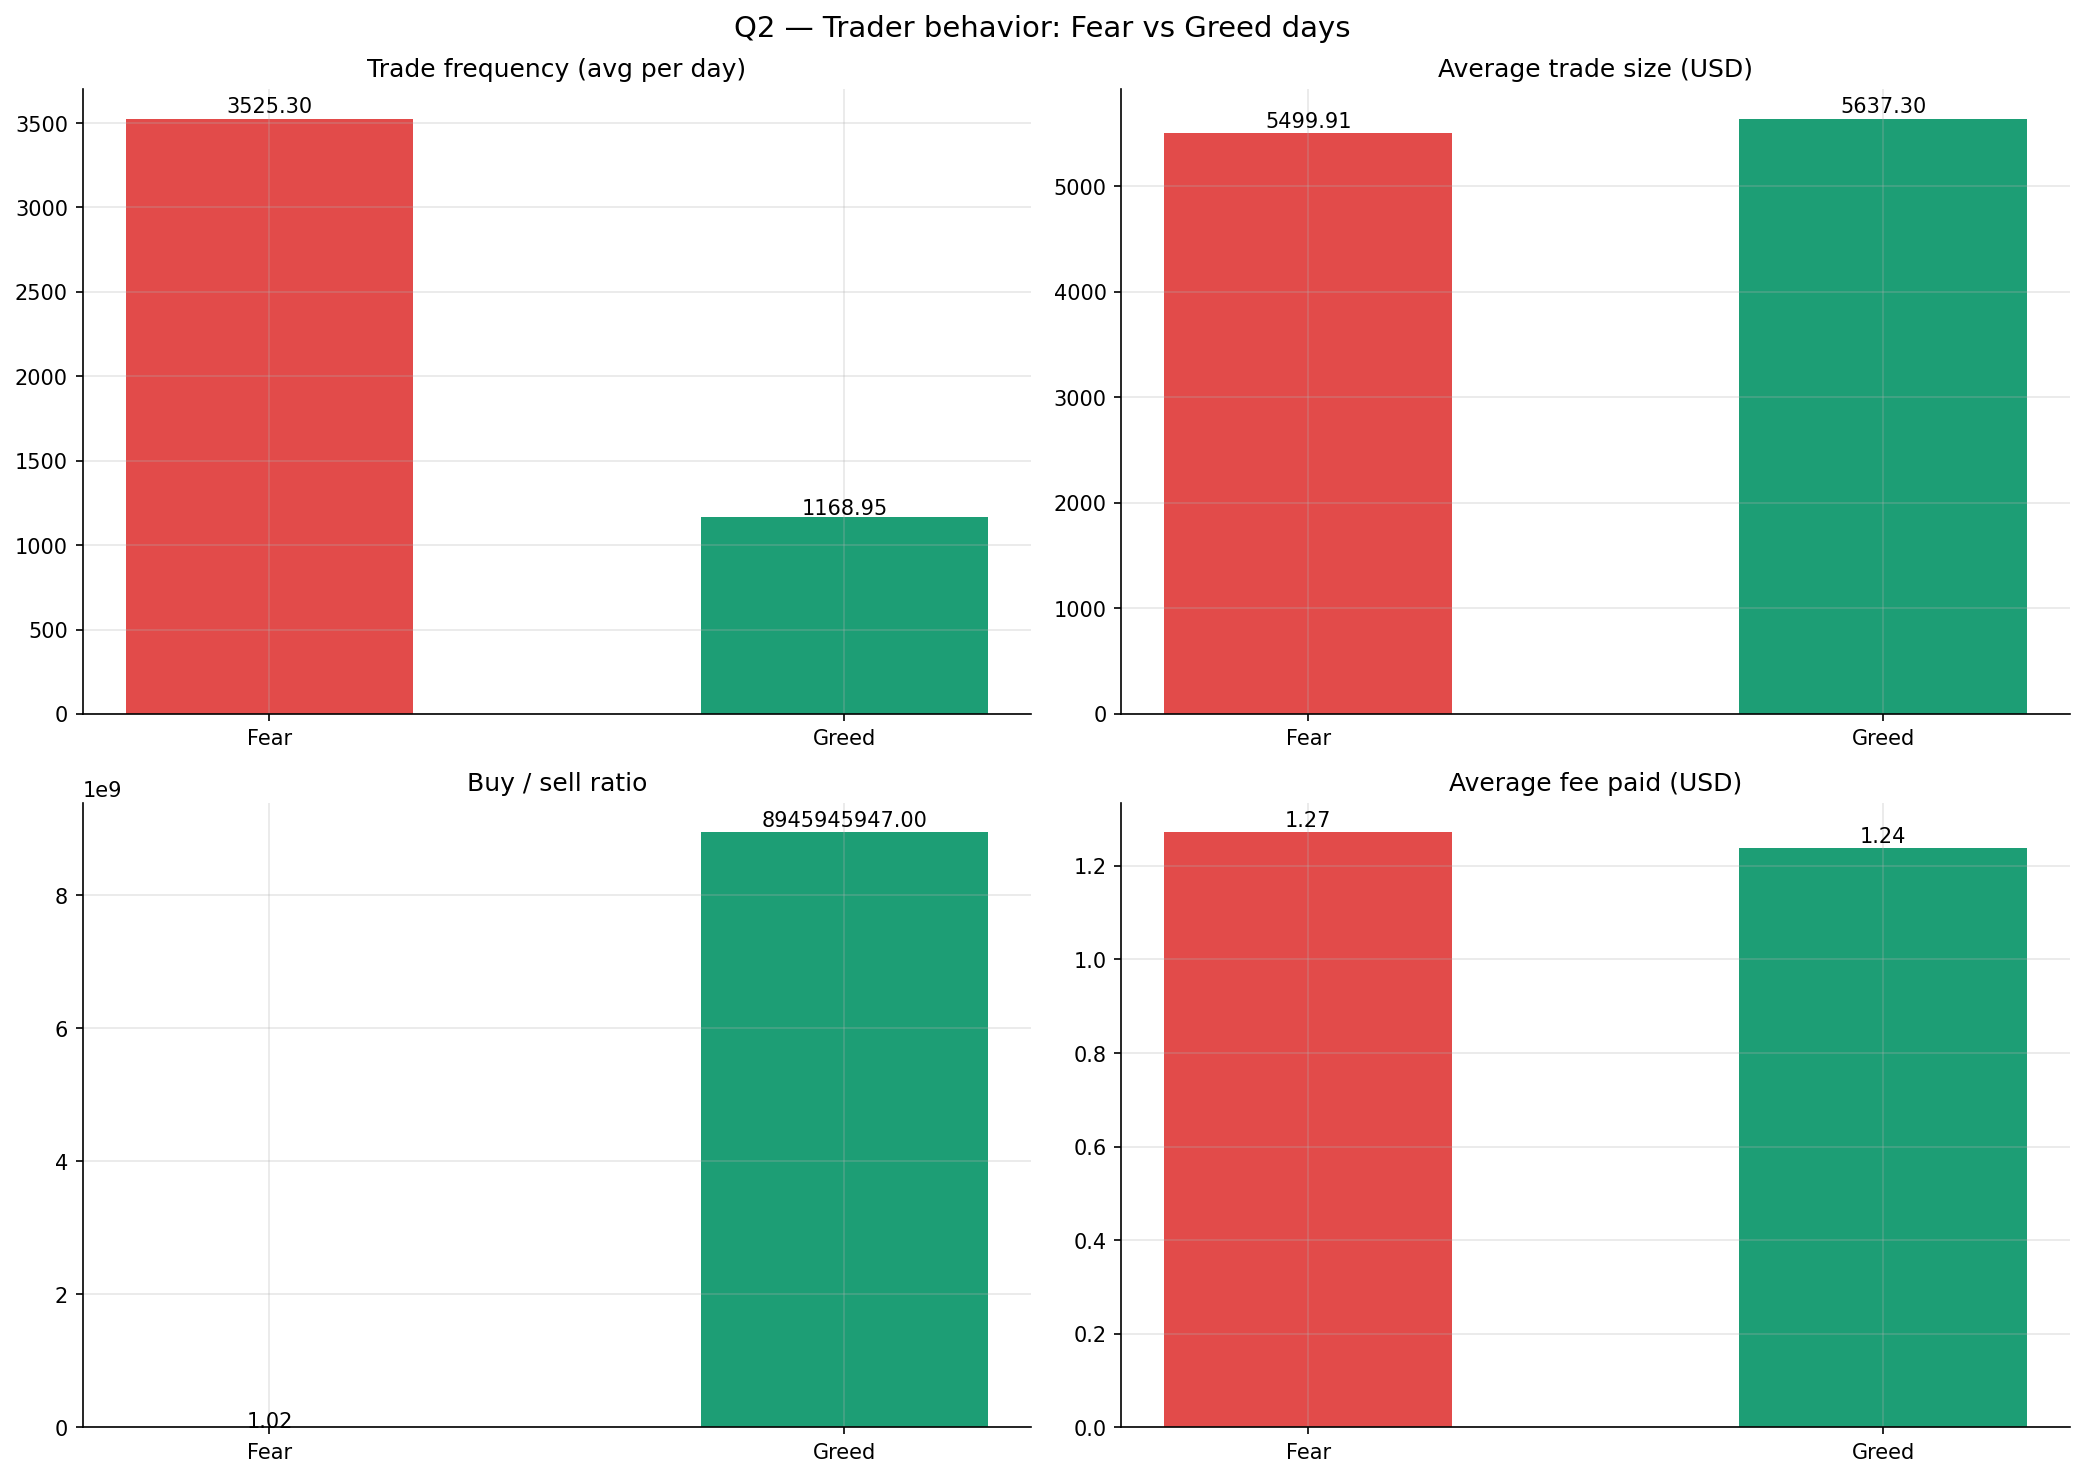

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = [PALETTE['Fear'], PALETTE['Greed']]
labels = ['Fear', 'Greed']

metrics = [
    ('num_trades',     'Trade frequency (avg per day)', axes[0,0]),
    ('avg_size_usd',   'Average trade size (USD)',      axes[0,1]),
    ('buy_sell_ratio', 'Buy / sell ratio',              axes[1,0]),
    ('avg_fee',        'Average fee paid (USD)',        axes[1,1]),
]

for col, title, ax in metrics:
    vals = [fear[col].mean(), greed[col].mean()]
    bars = ax.bar(labels, vals, color=colors, width=0.5)
    ax.set_title(title)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val * 1.01,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Q2 — Trader behavior: Fear vs Greed days', fontsize=14)
plt.tight_layout()
save_chart(fig, '07_q2_behavior.png')
plt.show()

## 4. Q3 — Segment analysis

In [9]:
daily_seg = daily.merge(
    traders[['Account','size_segment','frequency_segment','winner_segment']],
    on='Account', how='left'
)

seg_perf = daily_seg.groupby(['size_segment','Classification']).agg(
    mean_pnl = ('daily_pnl', 'mean'),
    win_rate = ('win_rate',  'mean'),
).round(4).reset_index()

print_section('SEGMENT ANALYSIS — Trade Size x Sentiment')
print(seg_perf.to_string(index=False))


  SEGMENT ANALYSIS — Trade Size x Sentiment
size_segment Classification    mean_pnl  win_rate
       Large           Fear 268906.0414    0.3323
       Large          Greed  16105.6481    0.2700
         Mid           Fear 156269.3798    0.4398
         Mid          Greed 156827.0544    0.3727
       Small           Fear  81729.3117    0.3864
       Small          Greed 118000.4463    0.4811


Chart saved: /app/charts/08_q3_segments.png


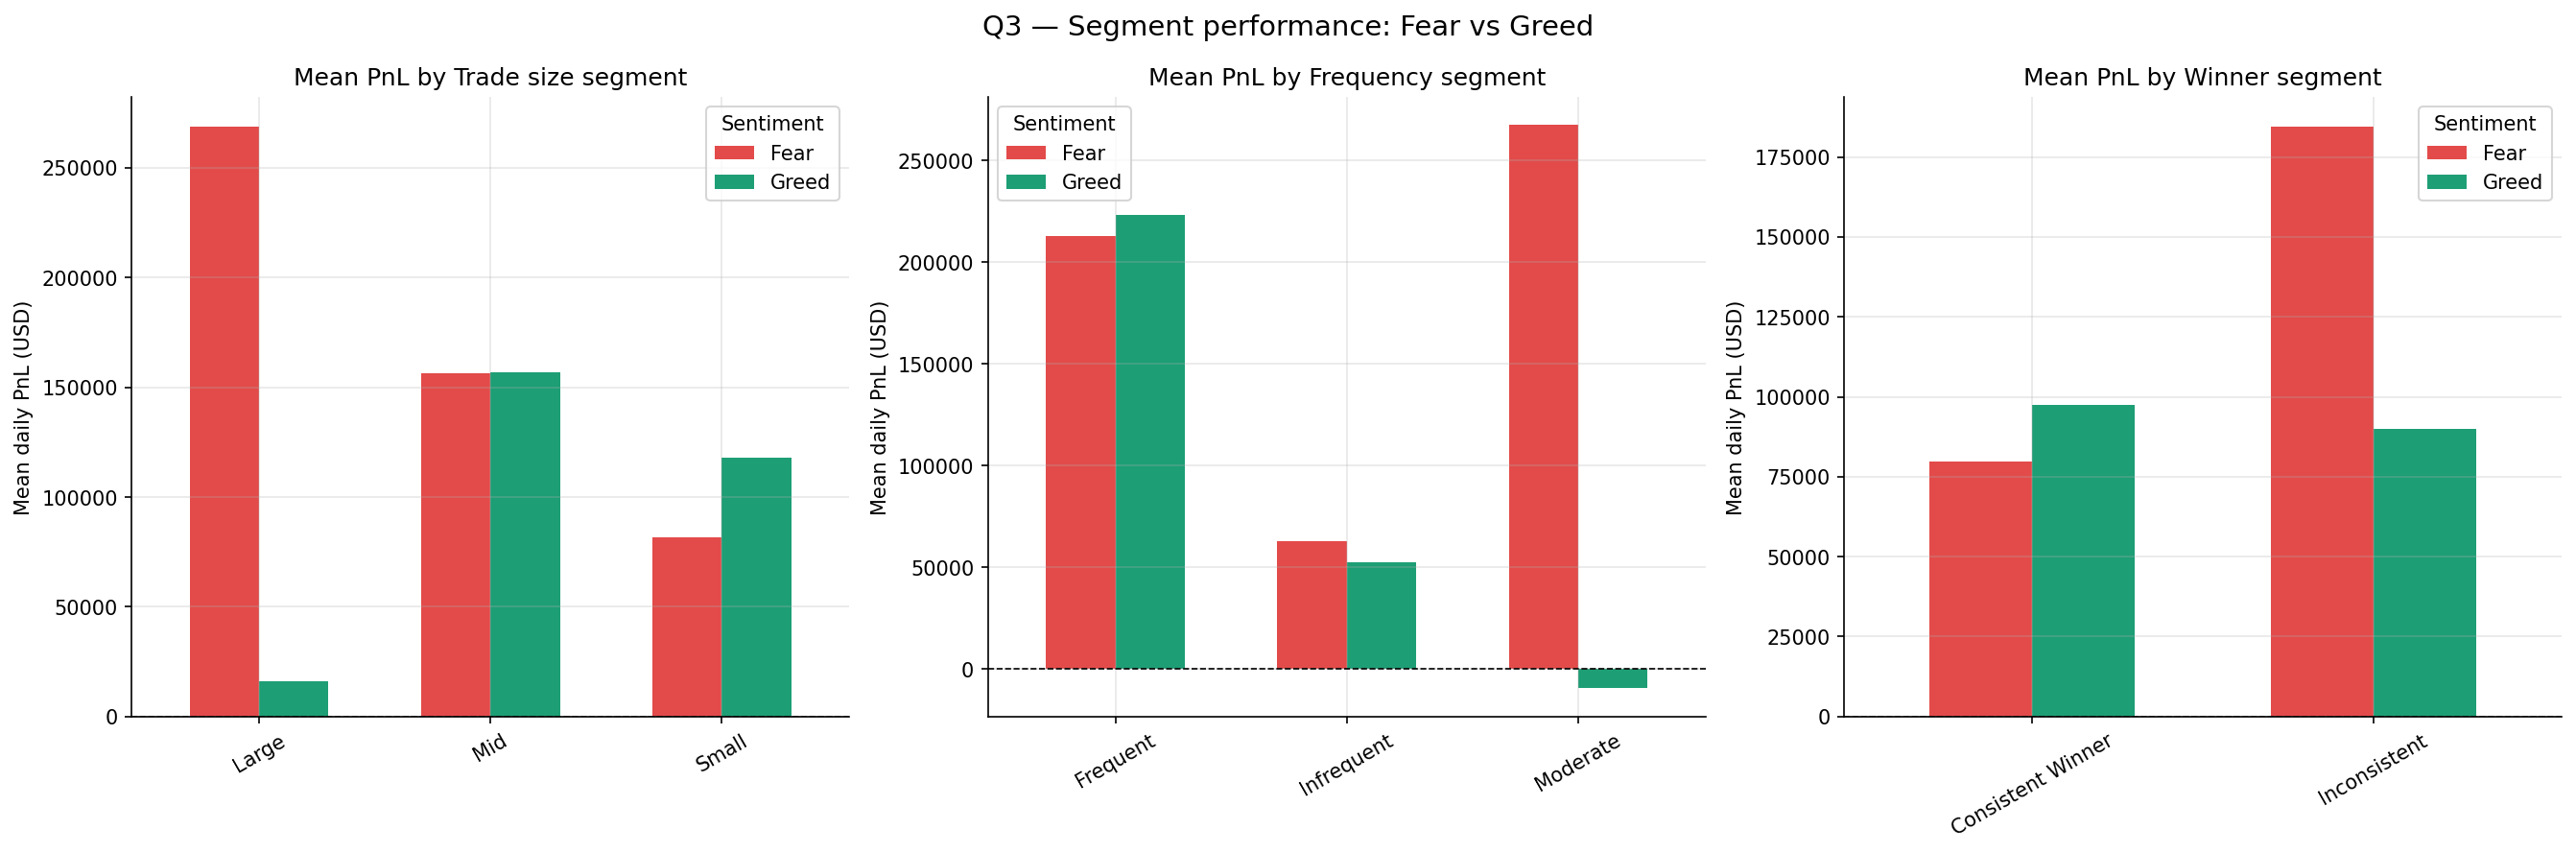

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
segments = ['size_segment', 'frequency_segment', 'winner_segment']
titles   = ['Trade size segment', 'Frequency segment', 'Winner segment']

for ax, seg, title in zip(axes, segments, titles):
    seg_data = daily_seg.groupby([seg,'Classification'])['daily_pnl'].mean().unstack()
    seg_data.plot(kind='bar', ax=ax,
                  color=[PALETTE['Fear'], PALETTE['Greed']],
                  width=0.6, rot=30)
    ax.set_title(f'Mean PnL by {title}')
    ax.set_ylabel('Mean daily PnL (USD)')
    ax.set_xlabel('')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(title='Sentiment')

plt.suptitle('Q3 — Segment performance: Fear vs Greed', fontsize=14)
plt.tight_layout()
save_chart(fig, '08_q3_segments.png')
plt.show()

## 5. Correlation heatmap

Chart saved: /app/charts/09_correlation_heatmap.png


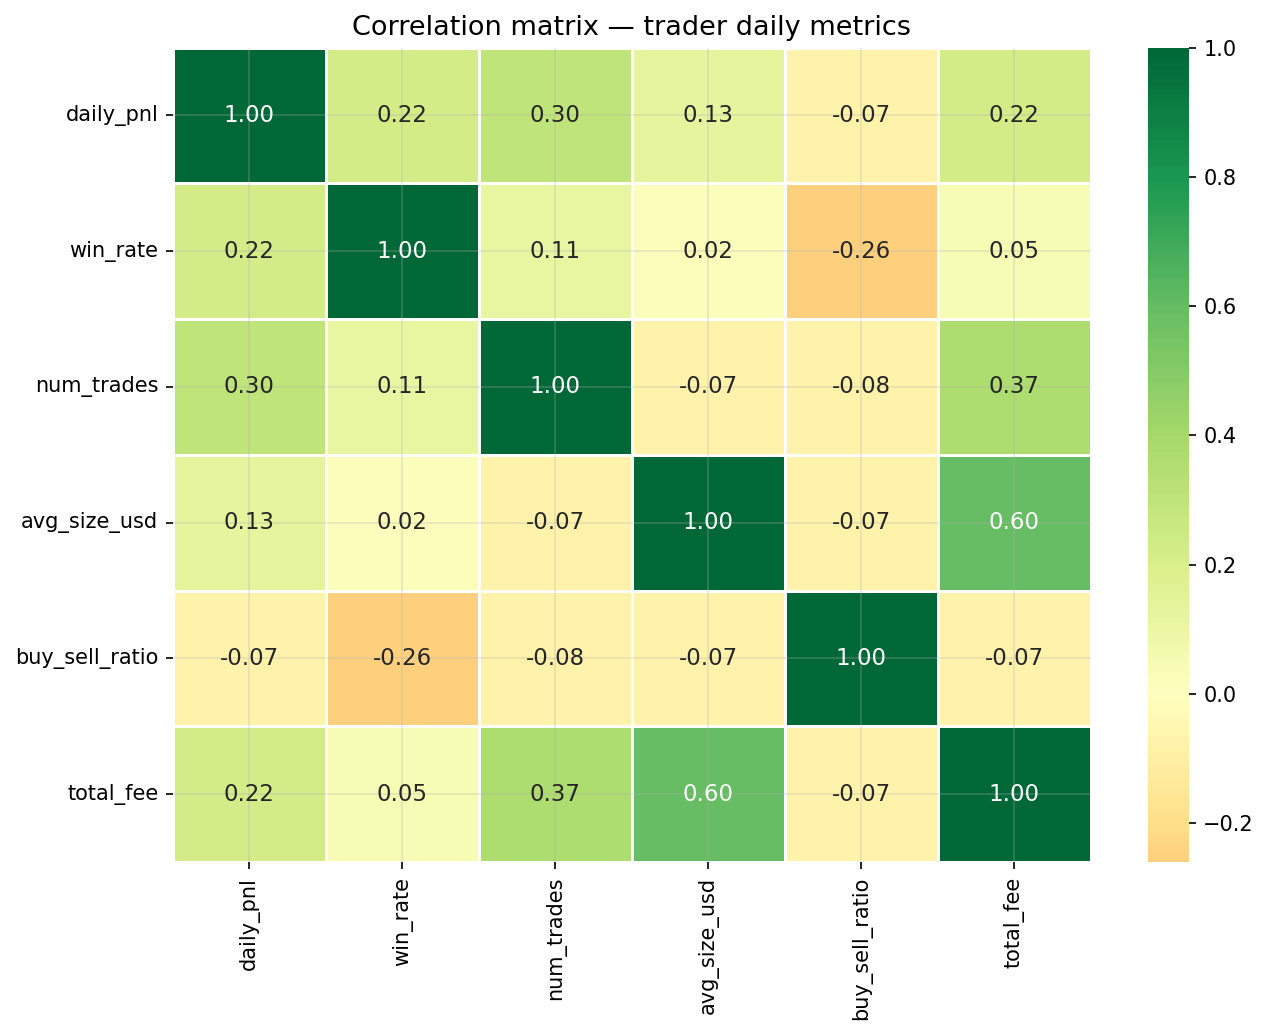

In [11]:
corr_cols = ['daily_pnl','win_rate','num_trades','avg_size_usd','buy_sell_ratio','total_fee']
corr = daily[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation matrix — trader daily metrics', fontsize=13)
plt.tight_layout()
save_chart(fig, '09_correlation_heatmap.png')
plt.show()

## 6. PnL over time by sentiment

Chart saved: /app/charts/10_pnl_over_time.png


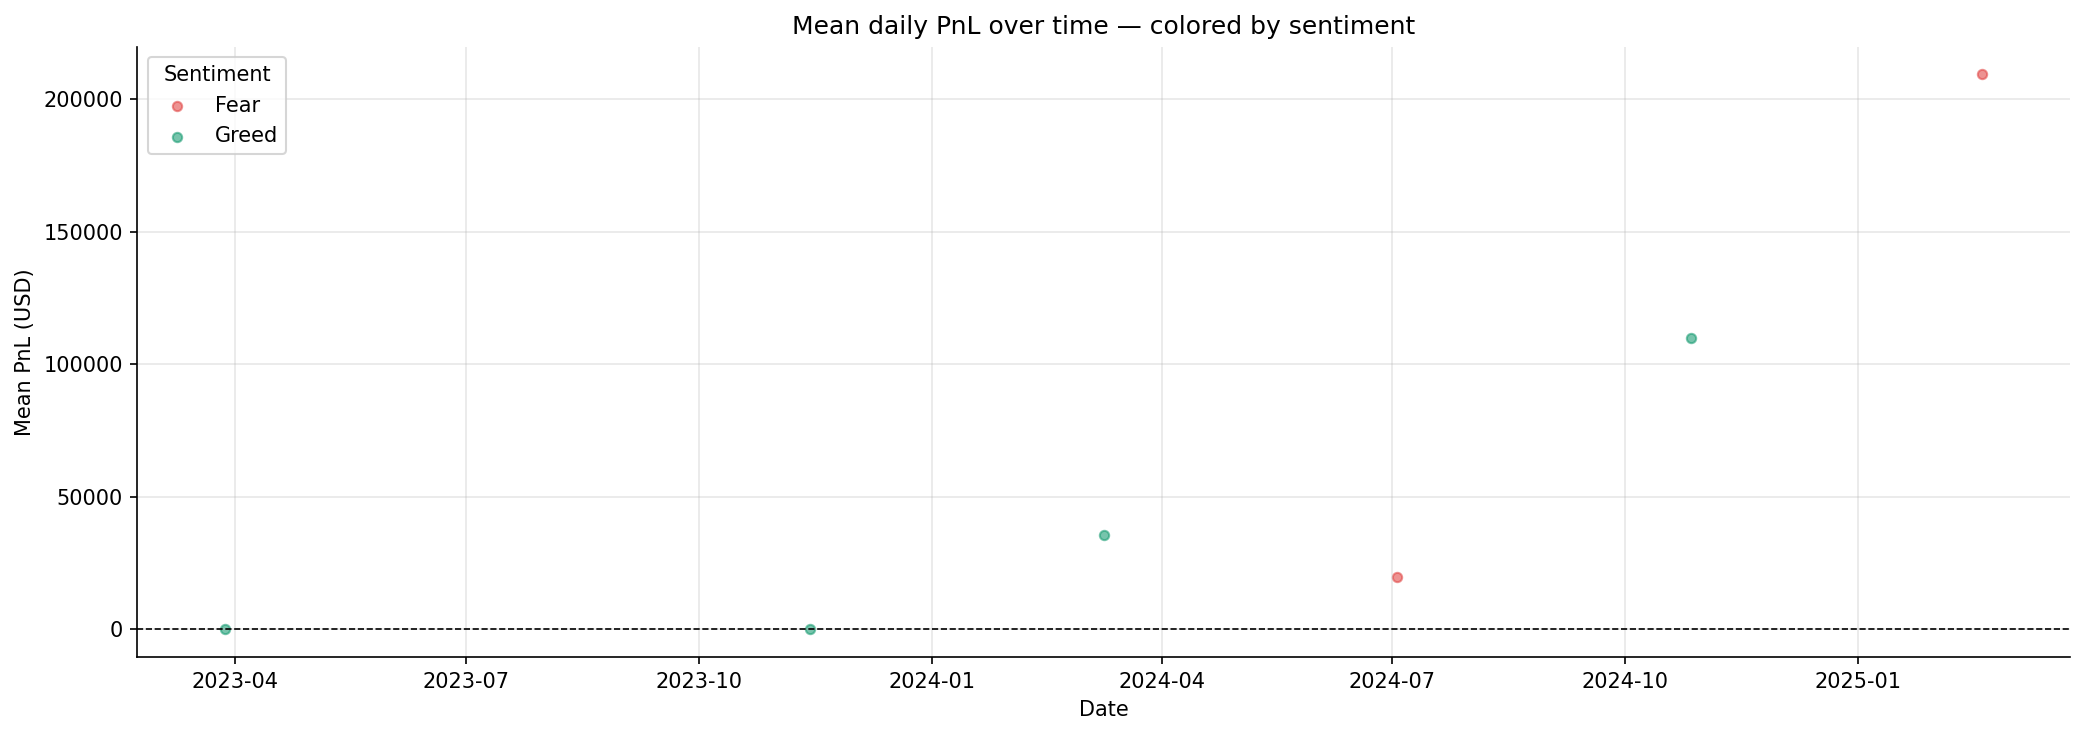

In [12]:
daily_agg = daily.groupby(['date','Classification'])['daily_pnl'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for label, color in [('Fear', PALETTE['Fear']), ('Greed', PALETTE['Greed'])]:
    subset = daily_agg[daily_agg['Classification'] == label]
    ax.scatter(subset['date'], subset['daily_pnl'],
               color=color, label=label, alpha=0.6, s=20)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Mean daily PnL over time — colored by sentiment')
ax.set_xlabel('Date')
ax.set_ylabel('Mean PnL (USD)')
ax.legend(title='Sentiment')
plt.tight_layout()
save_chart(fig, '10_pnl_over_time.png')
plt.show()

## 7. Top coins by PnL and sentiment

Chart saved: /app/charts/11_pnl_by_coin.png


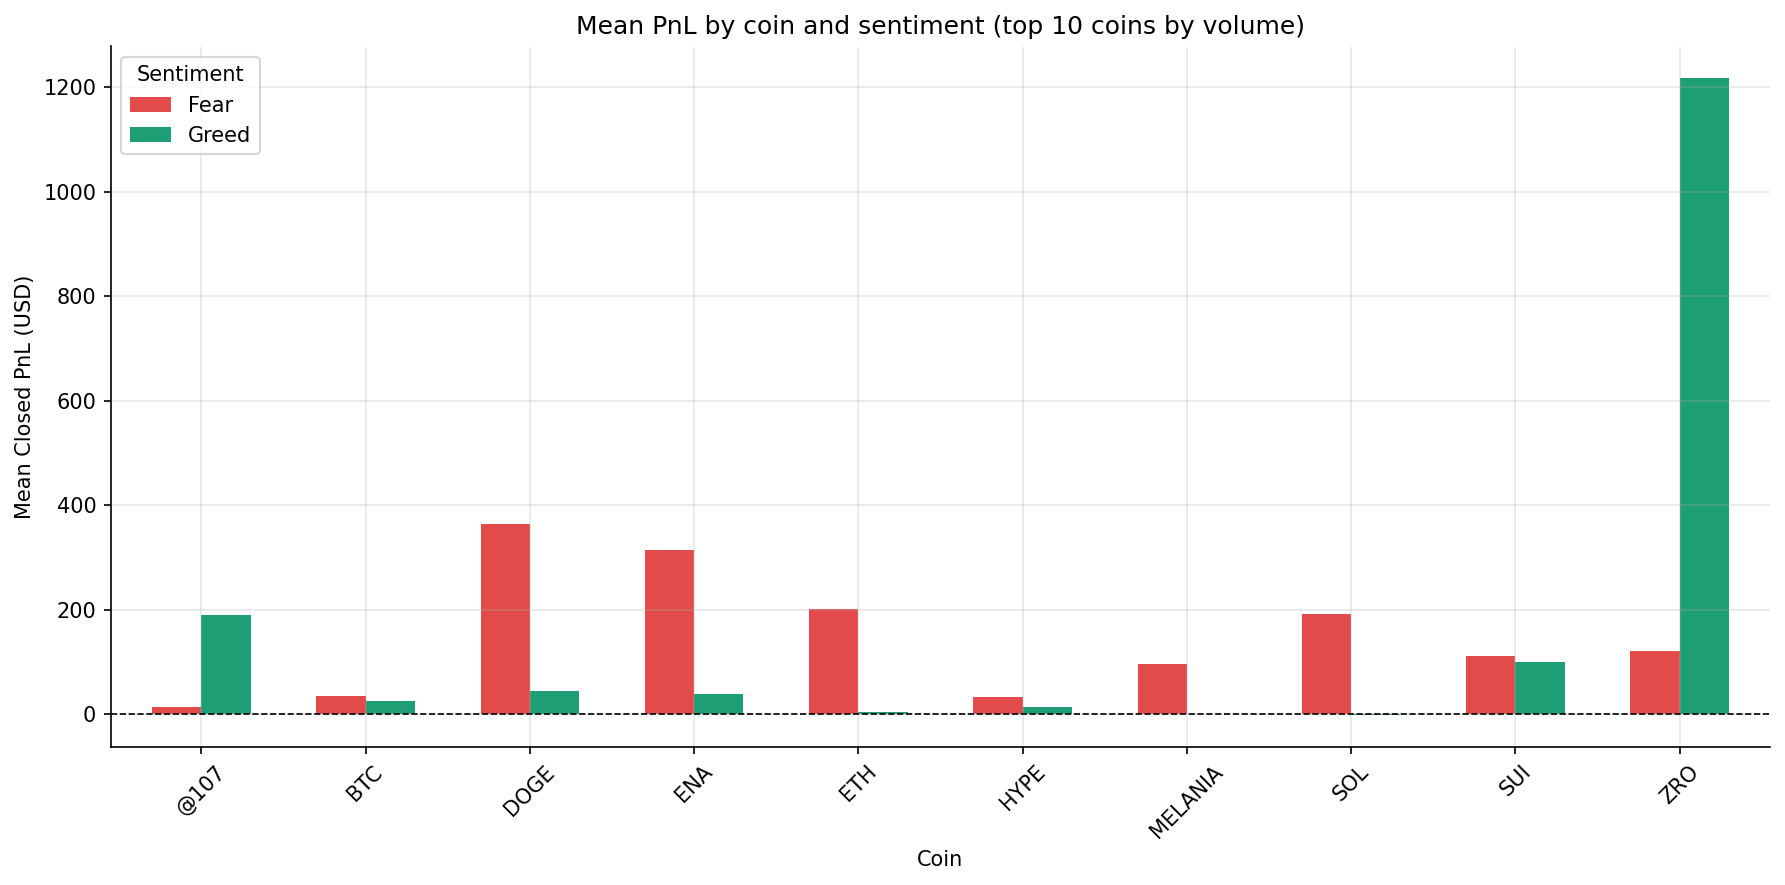

In [13]:
from src.config import MERGED_FILE
raw = pd.read_csv(MERGED_FILE)

coin_pnl = raw.groupby(['Coin','Classification'])['Closed PnL'].mean().unstack().fillna(0)
top_coins = raw.groupby('Coin')['Closed PnL'].sum().abs().nlargest(10).index
coin_pnl = coin_pnl.loc[coin_pnl.index.isin(top_coins)]

fig, ax = plt.subplots(figsize=(12, 6))
coin_pnl.plot(kind='bar', ax=ax,
              color=[PALETTE['Fear'], PALETTE['Greed']],
              width=0.6, rot=45)
ax.set_title('Mean PnL by coin and sentiment (top 10 coins by volume)')
ax.set_xlabel('Coin')
ax.set_ylabel('Mean Closed PnL (USD)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(title='Sentiment')
plt.tight_layout()
save_chart(fig, '11_pnl_by_coin.png')
plt.show()